In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout , Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix



In [20]:
url = "https://raw.githubusercontent.com/SJChesire/Flipkart-sentiment-analysis/main/flipkart_reviews.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(2304, 3)


,Product_name,Review,Rating
0,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Best under 60k Great performanceI got it for a...,5
1,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Good perfomence...,5
2,Lenovo Ideapad Gaming 3 Ryzen 5 Hexa Core 5600...,Great performance but usually it has also that...,5
3,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,My wife is so happy and best product 👌🏻😘,5
4,DELL Inspiron Athlon Dual Core 3050U - (4 GB/2...,"Light weight laptop with new amazing features,...",5


sentiment
1    1934
0     230
Name: count, dtype: int64


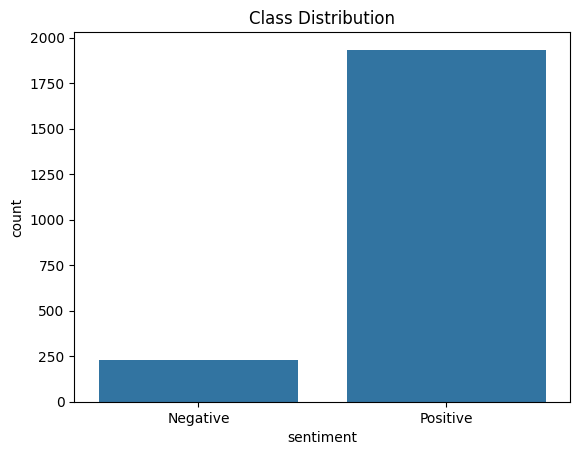

In [21]:
df = df[df['Rating'] != 3]

df['sentiment'] = df['Rating'].apply(lambda r: 1 if r >= 4 else 0)  # 1 = Positive, 0 = Negative

print(df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=df)
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title("Class Distribution")
plt.show()

dammm so much positive reviews.

In [22]:
#train test split
X = df['Review'].astype(str).values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(1731,) (433,)


In [23]:
#tokenize and padding
VOCAB_SIZE = 5000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(X_train_pad.shape, X_test_pad.shape)

(1731, 100) (433, 100)


In [24]:
#model architecture
EMBED_DIM = 64

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,137 (1.35 MB)

 Trainable params: 355,137 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#let's handle class imbalance . too much positive reviews
 # The dataset has far more positive reviews than negative, so weight classes accordingly
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    epochs=15,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Class weights: {0: np.float64(4.703804347826087), 1: np.float64(0.559469941822883)}
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2944 - loss: 0.7017 - val_accuracy: 0.0923 - val_loss: 0.7082
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7600 - loss: 0.6948 - val_accuracy: 0.3115 - val_loss: 0.6892
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8525 - loss: 0.6845 - val_accuracy: 0.9154 - val_loss: 0.6852
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6356 - loss: 0.6566 - val_accuracy: 0.9154 - val_loss: 0.6243
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8797 - loss: 0.6343 - val_accuracy: 0.8885 - val_loss: 0.6444
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7036 - loss: 0.6867 - val_accuracy: 0.9077 - val_loss: 0.6421
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5214 - loss: 0.7021 - val_accuracy: 0.9077 - val_loss: 0.6902


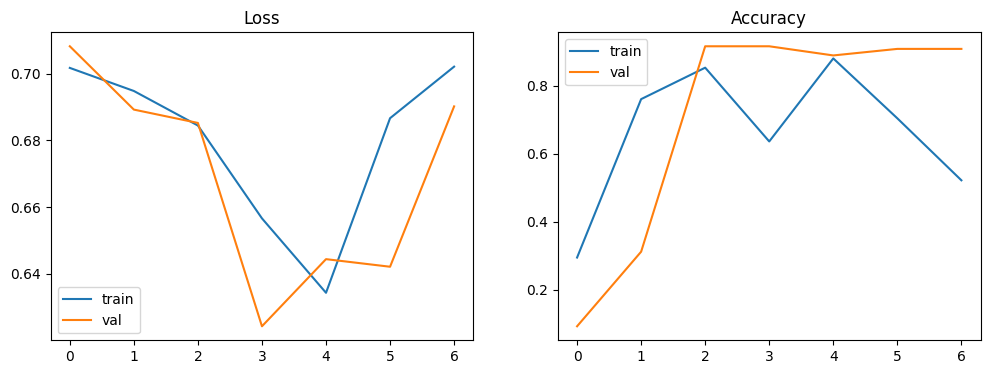

In [26]:
#let's see the training curve for better understanding
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy')
ax[1].legend()

plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9076 - loss: 0.6226
Test Accuracy: 0.9076
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

    Negative       1.00      0.13      0.23        46
    Positive       0.91      1.00      0.95       387

    accuracy                           0.91       433
   macro avg       0.95      0.57      0.59       433
weighted avg       0.92      0.91      0.87       433



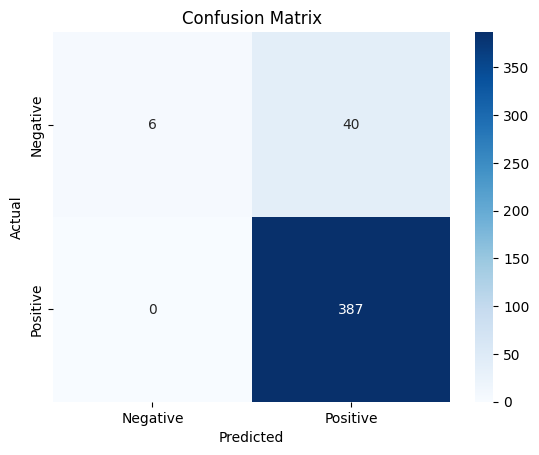

In [27]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [28]:
#test on your own
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = "Positive" if prob > 0.5 else "Negative"
    return label, float(prob)

samples = [
    "Amazing product but i din't liked the service of the delivery partner",
    "Very disappointed with the product but delivery was fast.",
    "Battery backup is great and the build quality feels premium."
    "Never buy this kind of cheap product so bad eww"
]

for s in samples:
    label, prob = predict_sentiment(s)
    print(f"Review: {s}\nPredicted: {label}  (confidence: {prob:.2f})\n")

Review: Amazing product but i din't liked the service of the delivery partner
Predicted: Positive  (confidence: 0.54)

Review: Very disappointed with the product but delivery was fast.
Predicted: Positive  (confidence: 0.54)

Review: Battery backup is great and the build quality feels premium.Never buy this kind of cheap product so bad eww
Predicted: Positive  (confidence: 0.54)

